In [39]:
import pandas as pd
import numpy as np

import geopandas as gpd
from shapely.geometry import Point, LineString
import skmob

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from mpl_chord_diagram import chord_diagram

In [40]:
# Import movement data
data_path = '../data/raw/movement.csv'

df = pd.read_csv(data_path)
df.head(2)

,licencePlate,car_type,vehicleTypeId,start_move_time,end_move_time,start_lat,start_lon,end_lat,end_lon,start_zip,end_zip,start_area_name,end_area_name,move_duration
0,bn32098,car,2,2025-07-22 09:13:29,2025-07-22 09:17:29,55.658398,12.514628,55.658348,12.515684,2500,2500.0,Valby,Valby,0 days 00:04:00
1,bn32098,car,2,2025-07-22 09:19:29,2025-07-22 09:23:29,55.658348,12.515684,55.659286,12.519309,2500,1805.0,Valby,Frederiksberg C,0 days 00:04:00


In [41]:
df.columns

Index(['licencePlate', 'car_type', 'vehicleTypeId', 'start_move_time',
       'end_move_time', 'start_lat', 'start_lon', 'end_lat', 'end_lon',
       'start_zip', 'end_zip', 'start_area_name', 'end_area_name',
       'move_duration'],
      dtype='object')

#### Inspecting missing values

In [42]:
# How many -1 in zip codes?
print("start_zip == -1:", (df['start_zip'] == -1).sum())
print("end_zip == -1:", (df['end_zip'] == -1).sum())

# What area names correspond to -1 zip codes?
print("\nArea names where start_zip == -1:")
print(df[df['start_zip'] == -1]['start_area_name'].value_counts())

print("\nArea names where end_zip == -1:")
print(df[df['end_zip'] == -1]['end_area_name'].value_counts())

start_zip == -1: 131
end_zip == -1: 134

Area names where start_zip == -1:
NOT_ANNOTATED    131
Name: start_area_name, dtype: int64

Area names where end_zip == -1:
NOT_ANNOTATED    134
Name: end_area_name, dtype: int64


In [43]:
df = df[df['start_zip'] != -1]
df = df[df['end_zip'] != -1]

# Verify
print("Remaining trips:", len(df))

Remaining trips: 469546


In [44]:
df = df[df['start_area_name'] != 'NOT_ANNOTATED']
df = df[df['end_area_name'] != 'NOT_ANNOTATED']

#### Build tessellation for flow

In [45]:
# OD matrix
ods = df[['start_area_name', 'end_area_name']].copy()
ods['flow'] = 1
flows = ods.groupby(['start_area_name', 'end_area_name']).flow.count().reset_index()

In [46]:
# Tessellation
tess_start = df[['start_area_name', 'start_lat', 'start_lon']].rename(columns={
    'start_area_name': 'tile_ID', 'start_lat': 'latitude', 'start_lon': 'longitude'
})
tess_end = df[['end_area_name', 'end_lat', 'end_lon']].rename(columns={
    'end_area_name': 'tile_ID', 'end_lat': 'latitude', 'end_lon': 'longitude'
})
tessellation = (
    pd.concat([tess_start, tess_end])
    .groupby('tile_ID')[['latitude', 'longitude']]
    .mean()
    .reset_index()
)

In [47]:
tessellation = (
    pd.concat([tess_start, tess_end])
    .groupby('tile_ID')[['latitude', 'longitude']]
    .mean()
    .reset_index()
)

In [48]:
tess = gpd.GeoDataFrame(
    tessellation,
    geometry=gpd.points_from_xy(tessellation.longitude, tessellation.latitude),
    crs='EPSG:4326'
)

In [49]:
# flows['start_zip'] = flows['start_zip'].astype(int).astype(str)
# flows['end_zip'] = flows['end_zip'].astype(float).astype(int).astype(str)
# tess['tile_ID'] = tess['tile_ID'].astype(float).astype(int).astype(str)

# # Verify they all look the same now
# print(flows['start_zip'].dtype, flows['start_zip'].iloc[0])
# print(flows['end_zip'].dtype, flows['end_zip'].iloc[0])
# print(tess['tile_ID'].dtype, tess['tile_ID'].iloc[0])

In [50]:
fdf = skmob.FlowDataFrame(
    flows,
    origin='start_area_name',
    destination='end_area_name',
    flow='flow',
    tessellation=tess,
    tile_id='tile_ID'
)

fdf.head()

,origin,destination,flow
0,Albertslund,Albertslund,1
1,Albertslund,Bagsvaerd,1
2,Albertslund,Bronshoj,6
3,Albertslund,Frederiksberg C,3
4,Albertslund,Glostrup,7


#### Plot tessellation

In [51]:
fdf.tessellation.head()

,tile_ID,latitude,longitude,geometry
0,Albertslund,55.670728,12.389820,POINT (12.38982 55.67073)
1,Bagsvaerd,55.757390,12.455336,POINT (12.45534 55.75739)
2,Ballerup,55.729227,12.359258,POINT (12.35926 55.72923)
3,Bronshoj,55.707218,12.488342,POINT (12.48834 55.70722)
4,Charlottelund,55.758048,12.573003,POINT (12.57300 55.75805)


In [52]:
# Visualise tesselation points
m1 = fdf.plot_tessellation(popup_features=['tile_ID'], zoom=10, tiles="cartodbpositron")
m1.save("../artifacts/tessellation_map.html")

In [53]:
m2 = fdf.plot_tessellation(popup_features=['tile_ID'], zoom=10, tiles="cartodbpositron")
fdf.plot_flows(min_flow=10, map_f=m2)

m2.save("../artifacts/flow_map.html")

### Time-of-the-day Analysis

In [54]:
# Create day buckets 
df['start_move_time'] = pd.to_datetime(df['start_move_time'])
df['hour'] = df['start_move_time'].dt.hour

def time_of_day(hour):
    if 6 <= hour < 10:
        return 'Morning (6-10)'
    elif 10 <= hour < 15:
        return 'Midday (10-15)'
    elif 15 <= hour < 19:
        return 'Afternoon (15-19)'
    else:
        return 'Night (19-6)'

df['time_of_day'] = df['hour'].apply(time_of_day)

In [55]:
# Flows per slice
def build_fdf_for_slice(df_slice, tess):
    ods = df_slice[['start_area_name', 'end_area_name']].copy()
    ods['flow'] = 1
    flows = ods.groupby(['start_area_name', 'end_area_name']).flow.count().reset_index()
    
    fdf_slice = skmob.FlowDataFrame(
        flows,
        origin='start_area_name',
        destination='end_area_name',
        flow='flow',
        tessellation=tess,
        tile_id='tile_ID'
    )
    return fdf_slice

#### Plot each time slice

In [56]:
time_slices = ['Morning (6-10)', 'Midday (10-15)', 'Afternoon (15-19)', 'Night (19-6)']

for slice_name in time_slices:
    df_slice = df[df['time_of_day'] == slice_name]
    fdf_slice = build_fdf_for_slice(df_slice, tess)
    
    m = fdf_slice.plot_tessellation(popup_features=['tile_ID'], zoom=11, tiles="cartodbpositron")
    fdf_slice.plot_flows(min_flow=5, map_f=m)
    m.save(f"../artifacts/flows_{slice_name.split()[0].lower()}.html")
    print(f"Saved: flows_{slice_name.split()[0].lower()}.html")

Saved: flows_morning.html
Saved: flows_midday.html
Saved: flows_afternoon.html
Saved: flows_night.html


In [57]:
# Size tessellation points by popularity
# Calculate total trips per area
area_popularity = (
    df.groupby('start_area_name').size() + df.groupby('end_area_name').size()
).reset_index()
area_popularity.columns = ['tile_ID', 'total_trips']

# Merge into tessellation
tess = tess.merge(area_popularity, on='tile_ID', how='left').fillna(0)

# Plot with sized points
m = fdf.plot_tessellation(
    popup_features=['tile_ID', 'total_trips'],
    zoom=11,
    tiles="cartodbpositron"
)
fdf.plot_flows(min_flow=10, map_f=m)
m.save("../artifacts/flows_sized.html")

### Chord diagram

In [58]:
# pip install holoviews bokeh plotly chord mpl-chord-diagram

In [59]:
time_slices = {
    'Morning (6-10)': (6, 10),
    'Midday (10-15)': (10, 15),
    'Afternoon (15-19)': (15, 19),
    'Night (19-6)': (19, 6)
}

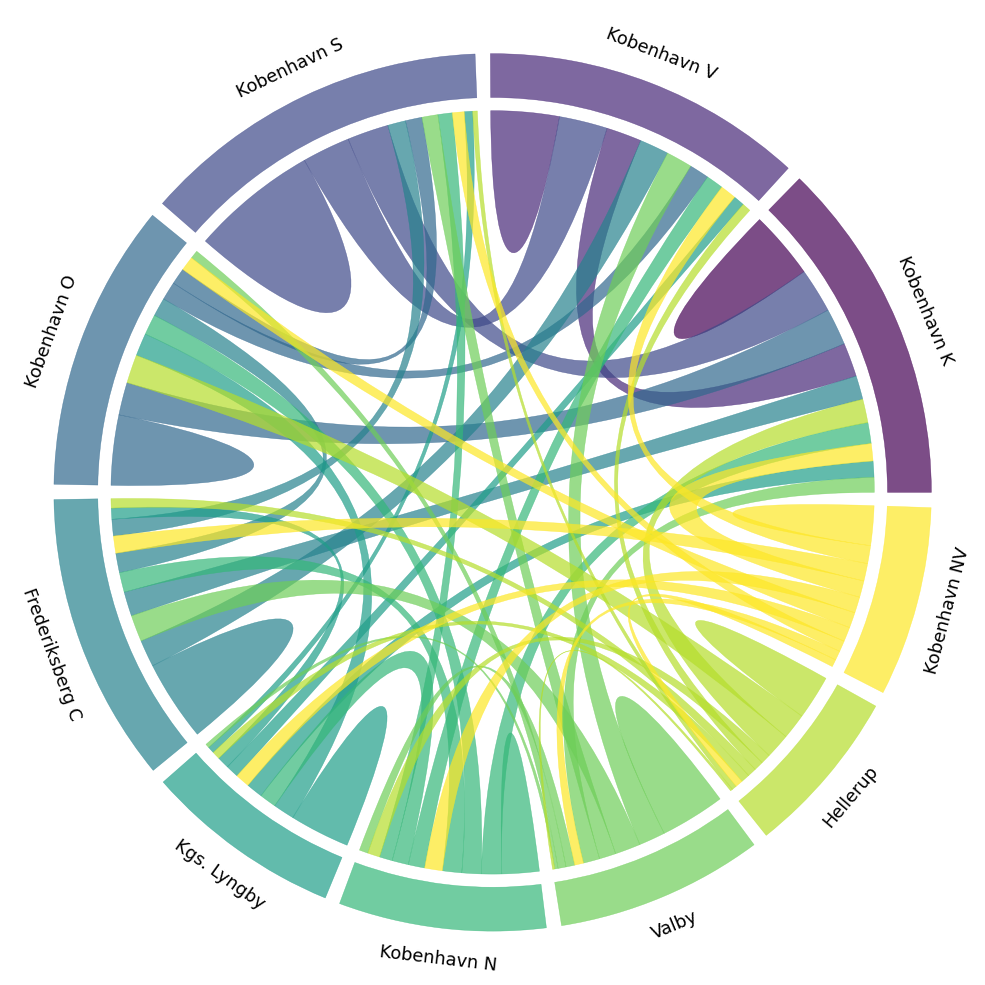

In [60]:
N = 10
top_areas = (
    fdf.groupby('origin')['flow'].sum() + fdf.groupby('destination')['flow'].sum()
).sort_values(ascending=False).head(N).index.tolist()

chord_data = fdf[
    fdf['origin'].isin(top_areas) & 
    fdf['destination'].isin(top_areas)
][['origin', 'destination', 'flow']].copy()

area_idx = {area: i for i, area in enumerate(top_areas)}

# Build matrix
matrix = np.zeros((N, N))
for _, row in chord_data.iterrows():
    i = area_idx[row['origin']]
    j = area_idx[row['destination']]
    matrix[i][j] = row['flow']

fig, ax = plt.subplots(figsize=(10, 10))
chord_diagram(matrix, top_areas, ax=ax)
plt.savefig("../artifacts/chord_diagram.png", dpi=150, bbox_inches='tight')
plt.show()

In [61]:
print(df['start_area_name'].unique())


['Valby' 'Frederiksberg C' 'Kobenhavn SV' 'Kastrup' 'Kobenhavn S'
 'Kobenhavn V' 'Kobenhavn N' 'Kobenhavn K' 'Gentofte' 'Kobenhavn O'
 'Charlottelund' 'Kgs. Lyngby' 'Hellerup' 'Kobenhavn NV' 'Soborg'
 'Bagsvaerd' 'Rodovre' 'Herlev' 'Nordhavn' 'Hvidovre' 'Glostrup'
 'Bronshoj' 'Skovlunde' 'Klampenborg' 'Vanlose' 'Dyssegoord' 'Taastrup'
 'Virum' 'Albertslund' 'Ballerup']


#### CPH vs rest

In [62]:
# Define Copenhagen areas
copenhagen = [
    'Kobenhavn K', 'Kobenhavn V', 'Kobenhavn S', 'Kobenhavn N',
    'Kobenhavn O', 'Kobenhavn NV', 'Kobenhavn SV', 'Nordhavn',
    'Valby', 'Vanlose', 'Bronshoj'
]

# Map areas to groups
def group_area(area):
    if area in copenhagen:
        return 'Copenhagen'
    return area  # keep suburban areas as individual

df['area_group_start'] = df['start_area_name'].apply(group_area)
df['area_group_end'] = df['end_area_name'].apply(group_area)

# Build flows on grouped areas
ods_grouped = df[['area_group_start', 'area_group_end']].copy()
ods_grouped['flow'] = 1
flows_grouped = ods_grouped.groupby(['area_group_start', 'area_group_end']).flow.count().reset_index()

print(flows_grouped.sort_values('flow', ascending=False).head(10))

    area_group_start   area_group_end    flow
57        Copenhagen       Copenhagen  157610
94   Frederiksberg C       Copenhagen   16581
59        Copenhagen  Frederiksberg C   16465
66        Copenhagen      Kgs. Lyngby    9514
226      Kgs. Lyngby       Copenhagen    9510
62        Copenhagen         Hellerup    8502
150         Hellerup       Copenhagen    8198
207          Kastrup       Copenhagen    7999
65        Copenhagen          Kastrup    7930
60        Copenhagen         Gentofte    7492


Top 10 areas: ['Copenhagen', 'Frederiksberg C', 'Kgs. Lyngby', 'Hellerup', 'Gentofte', 'Charlottelund', 'Kastrup', 'Soborg', 'Rodovre', 'Dyssegoord']


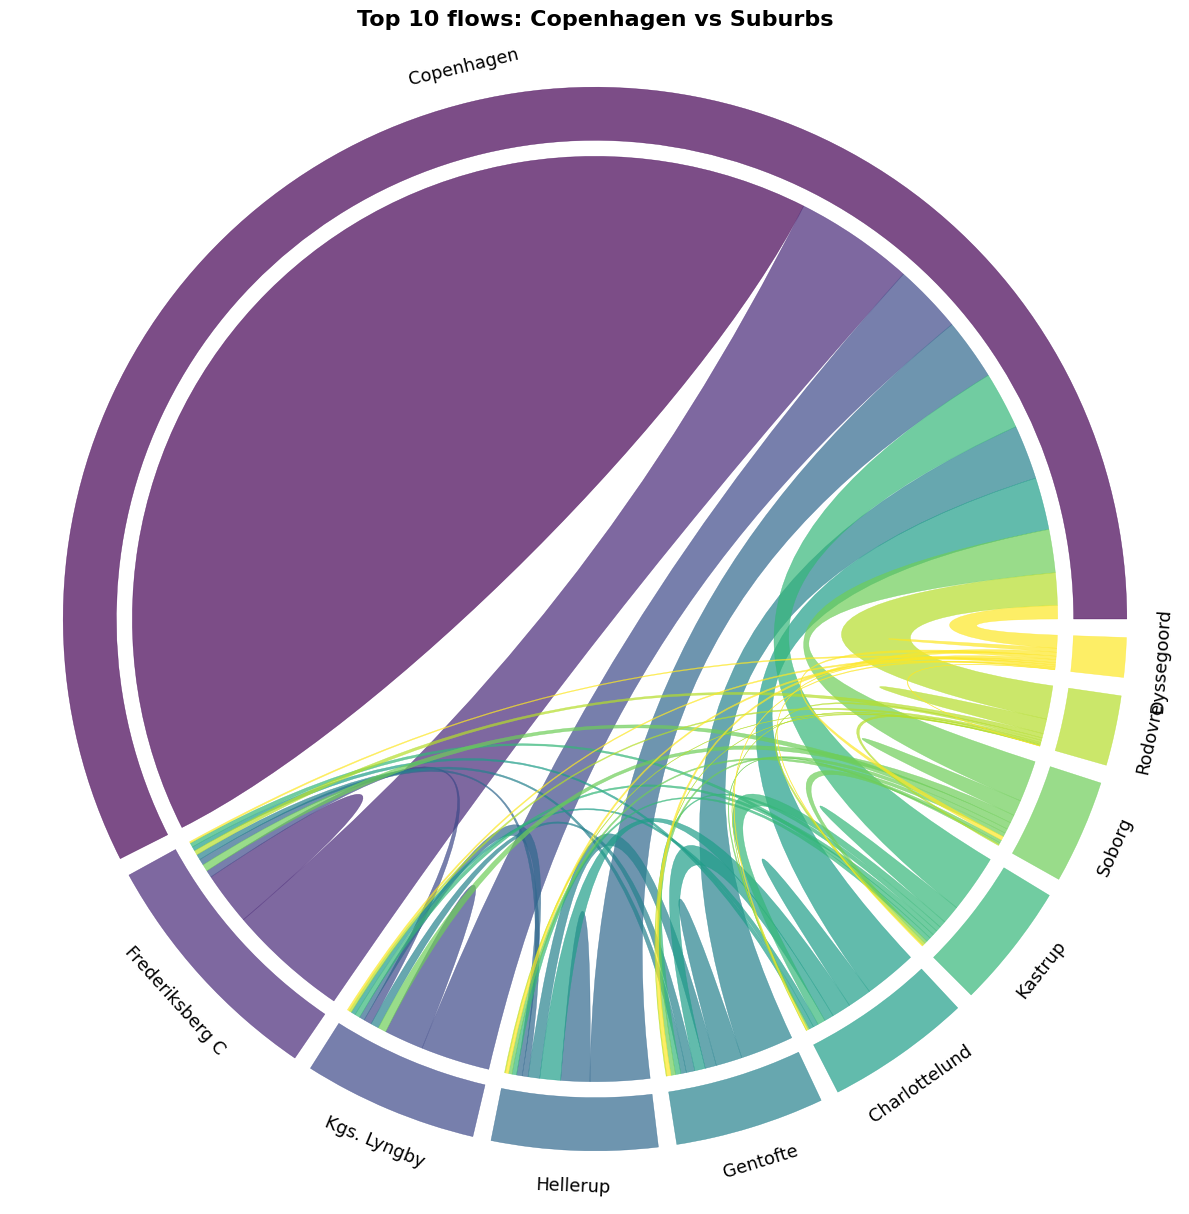

In [63]:
# Get top 10 areas by total flow
top_10 = (
    flows_grouped.groupby('area_group_start')['flow'].sum() + 
    flows_grouped.groupby('area_group_end')['flow'].sum()
).sort_values(ascending=False).head(10).index.tolist()

print("Top 10 areas:", top_10)

# Filter flows to only top 10
flows_top10 = flows_grouped[
    flows_grouped['area_group_start'].isin(top_10) &
    flows_grouped['area_group_end'].isin(top_10)
]

# Build matrix
area_idx = {area: i for i, area in enumerate(top_10)}
N = len(top_10)

matrix = np.zeros((N, N))
for _, row in flows_top10.iterrows():
    i = area_idx[row['area_group_start']]
    j = area_idx[row['area_group_end']]
    matrix[i][j] = row['flow']

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
chord_diagram(matrix, top_10, ax=ax)
plt.title('Top 10 flows: Copenhagen vs Suburbs', fontsize=16, fontweight='bold')
plt.savefig("chord_top10_grouped.png", dpi=150, bbox_inches='tight')
plt.show()